In [3]:
#%pip install scipy

In [10]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 프로젝트 루트
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

AUCTION_DIR = PROJECT_ROOT / "data" / "raw" / "garak" / "auction"
ARRIVAL_DIR = PROJECT_ROOT / "data" / "raw" / "garak" / "arrival"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("AUCTION_DIR  :", AUCTION_DIR)
print("ARRIVAL_DIR  :", ARRIVAL_DIR)

PROJECT_ROOT : /Users/yoon/Documents/code/5PL
AUCTION_DIR  : /Users/yoon/Documents/code/5PL/data/raw/garak/auction
ARRIVAL_DIR  : /Users/yoon/Documents/code/5PL/data/raw/garak/arrival


In [12]:
SELECTED_ITEMS = [
    "키위",
    "블루베리",
    "망고"
]

CALIBRATION_START = "2022-01-01"
CALIBRATION_END = "2022-01-31"

In [14]:
auction_raw = pd.read_csv(
    AUCTION_FILE
)

print("경매 데이터 행 수:", len(auction_raw))
print("컬럼:")
print(auction_raw.columns.tolist())

display(auction_raw.head())

경매 데이터 행 수: 392
컬럼:
['ADJ_DT', 'DDD', 'PPRICE', 'PUM_NAME_IMSI', 'CORP_NM', 'UUN', 'ROWNO', 'PUMMOK', 'QTY', 'PUMJONG', 'INJUNG_GUBUN', 'SSANGI', '_query_date', '_query_item', 'unit_kg', 'trade_qty_kg', 'price_per_kg']


,ADJ_DT,DDD,PPRICE,PUM_NAME_IMSI,CORP_NM,UUN,ROWNO,PUMMOK,QTY,PUMJONG,INJUNG_GUBUN,SSANGI,_query_date,_query_item,unit_kg,trade_qty_kg,price_per_kg
0,2022-01-03,특(1등),15000,[키위]골드키위(2팀국산),서울청과,5.6kg,1,키위,19,골드키위(2팀국산),일반,제주 제주시,20220103,키위,5.6,106.4,2678.571429
1,2022-01-03,특(1등),38000,[키위]키위(2팀국산),서울청과,10kg,2,키위,50,키위(2팀국산),일반,전남 보성군,20220103,키위,10.0,500.0,3800.000000
2,2022-01-03,특(1등),48000,[망고]망고(수입),서울청과,10kg,1,망고,2,망고(수입),일반,수입산 베트남,20220103,망고,10.0,20.0,4800.000000
3,2022-01-03,특(1등),42000,[망고]망고(수입),서울청과,10kg,2,망고,1,망고(수입),일반,수입산 페루,20220103,망고,10.0,10.0,4200.000000
4,2022-01-03,특(1등),42000,[망고]망고(수입),서울청과,10kg,3,망고,1,망고(수입),일반,수입산 페루,20220103,망고,10.0,10.0,4200.000000


In [15]:
arrival_raw = pd.read_csv(
    ARRIVAL_FILE
)

print("반입 데이터 행 수:", len(arrival_raw))
print("컬럼:")
print(arrival_raw.columns.tolist())

display(arrival_raw.head())

반입 데이터 행 수: 87
컬럼:
['date', 'category', 'item', 'total_arrival']


,date,category,item,total_arrival
0,20220101,과일류,키위,8.6680
1,20220101,과일류,망고,3.9390
2,20220101,과일류,블루베리,1.8555
3,20220102,과일류,키위,0.1120
4,20220104,과일류,키위,7.0570


### Seller 측 공급량 분포

In [16]:
arrival = arrival_raw.copy()

# 날짜 변환
arrival["date"] = pd.to_datetime(
    arrival["date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 반입량 숫자형 변환
arrival["total_arrival"] = pd.to_numeric(
    arrival["total_arrival"],
    errors="coerce"
)

# 최종 3개 품목만 다시 확인
arrival = arrival[
    arrival["item"].isin(SELECTED_ITEMS)
].copy()

arrival = arrival.sort_values(
    ["date", "item"]
).reset_index(drop=True)

print("행 수:", len(arrival))
print("\n품목별 관측일수:")
display(
    arrival.groupby("item")["date"]
    .nunique()
)

display(arrival.head(15))

행 수: 87

품목별 관측일수:


item
망고      29
블루베리    29
키위      29
Name: date, dtype: int64

,date,category,item,total_arrival
0,2022-01-01,과일류,망고,3.9390
1,2022-01-01,과일류,블루베리,1.8555
2,2022-01-01,과일류,키위,8.6680
3,2022-01-02,과일류,키위,0.1120
4,2022-01-04,과일류,망고,7.8580
5,2022-01-04,과일류,블루베리,1.6185
6,2022-01-04,과일류,키위,7.0570
7,2022-01-05,과일류,망고,3.1230
8,2022-01-05,과일류,블루베리,3.1275
9,2022-01-05,과일류,키위,5.4674


In [17]:
duplicate_check = (
    arrival
    .groupby(["date", "item"])
    .size()
    .reset_index(name="n")
)

duplicates = duplicate_check[
    duplicate_check["n"] > 1
]

print("중복 date-item 개수:", len(duplicates))

display(duplicates.head())

중복 date-item 개수: 0


,date,item,n


In [18]:
daily_arrival = (
    arrival
    .groupby(["date", "item"], as_index=False)
    .agg(
        arrival_qty=("total_arrival", "sum")
    )
)

display(daily_arrival.head(20))

,date,item,arrival_qty
0,2022-01-01,망고,3.9390
1,2022-01-01,블루베리,1.8555
2,2022-01-01,키위,8.6680
3,2022-01-02,키위,0.1120
4,2022-01-04,망고,7.8580
5,2022-01-04,블루베리,1.6185
6,2022-01-04,키위,7.0570
7,2022-01-05,망고,3.1230
8,2022-01-05,블루베리,3.1275
9,2022-01-05,키위,5.4674


In [19]:
arrival_summary = (
    daily_arrival
    .groupby("item")["arrival_qty"]
    .agg(
        active_days="count",
        total="sum",
        mean="mean",
        std="std",
        median="median",
        q10=lambda x: x.quantile(0.10),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        min="min",
        max="max"
    )
)

arrival_summary["cv"] = (
    arrival_summary["std"]
    / arrival_summary["mean"]
)

display(arrival_summary)

,active_days,total,mean,std,median,q10,q25,q75,q90,min,max,cv
item,,,,,,,,,,,,
망고,29,257.6910,8.885897,6.065780,7.5480,1.70660,4.5310,12.8045,19.06190,0.3950,19.7655,0.682630
블루베리,29,69.9318,2.411441,1.602860,2.3136,0.63586,1.4490,3.1275,4.44690,0.0915,6.8085,0.664689
키위,29,198.0242,6.828421,4.265454,5.6624,2.43696,4.4223,9.1688,12.24716,0.1120,17.2776,0.624662


/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yoon/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yoon/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


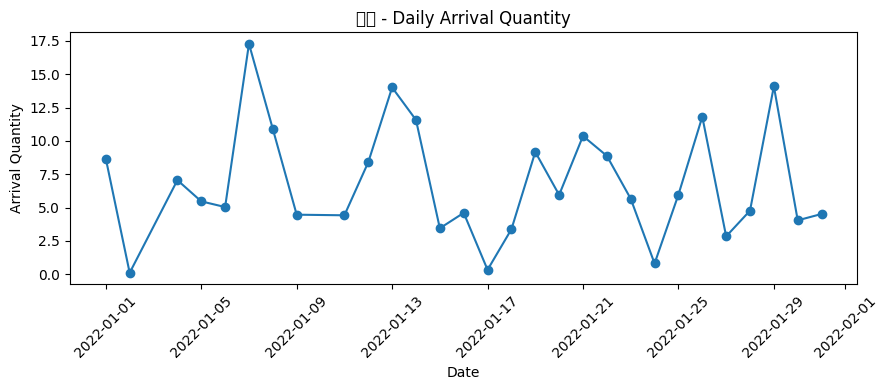

/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 47336 (\N{HANGUL SYLLABLE RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yoon/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yoon/Library/Python/3.9/lib

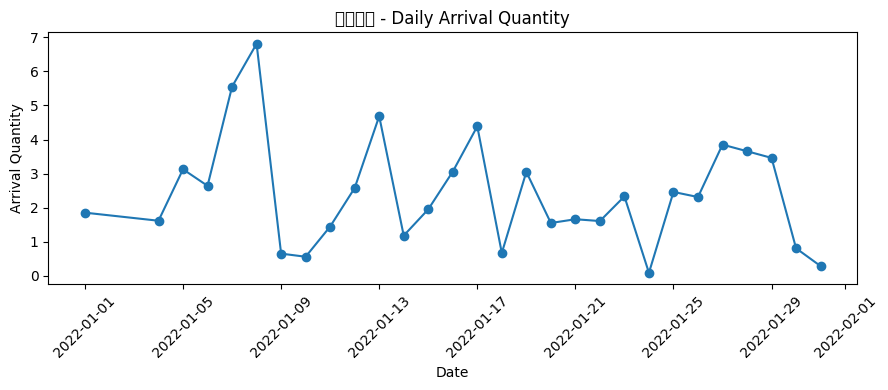

/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3294837519.py:19: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yoon/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yoon/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


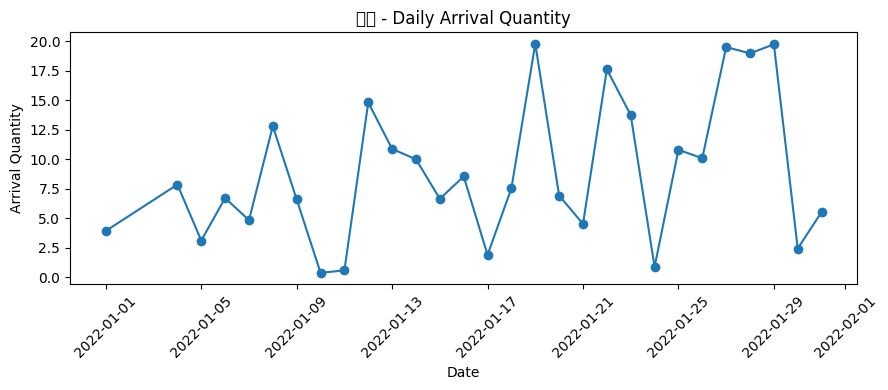

In [20]:
for item in SELECTED_ITEMS:

    temp = daily_arrival[
        daily_arrival["item"] == item
    ].sort_values("date")

    plt.figure(figsize=(9, 4))

    plt.plot(
        temp["date"],
        temp["arrival_qty"],
        marker="o"
    )

    plt.title(f"{item} - Daily Arrival Quantity")
    plt.xlabel("Date")
    plt.ylabel("Arrival Quantity")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


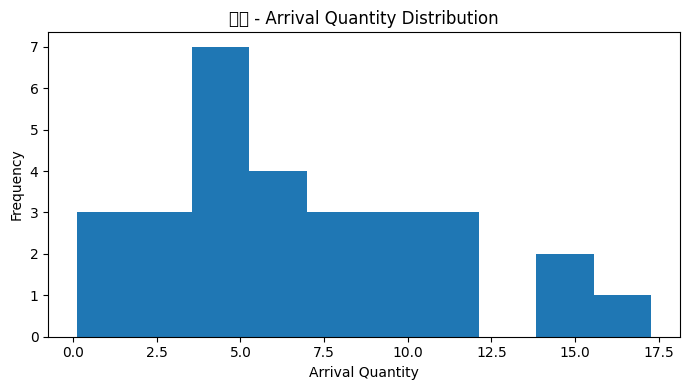

/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 47336 (\N{HANGUL SYLLABLE RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


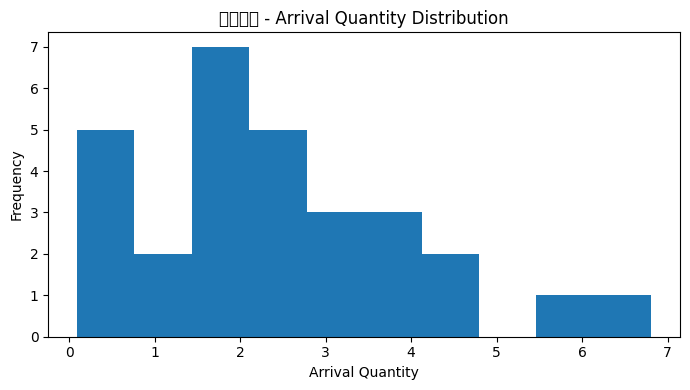

/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rn/s_fzr1s55dj49blh6qqvgbt80000gn/T/ipykernel_7376/3690363420.py:18: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


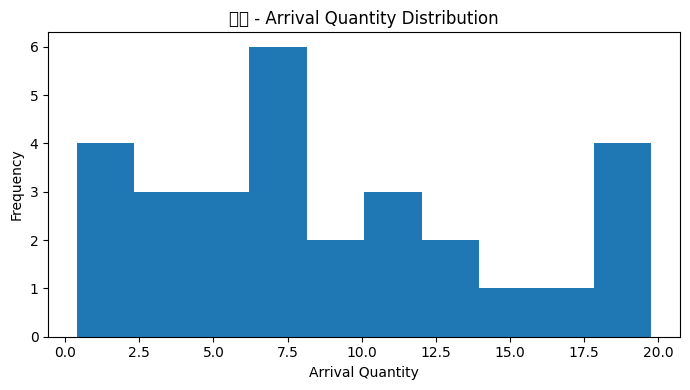

In [21]:
for item in SELECTED_ITEMS:

    x = daily_arrival.loc[
        daily_arrival["item"] == item,
        "arrival_qty"
    ].dropna()

    plt.figure(figsize=(7, 4))

    plt.hist(
        x,
        bins=10
    )

    plt.title(f"{item} - Arrival Quantity Distribution")
    plt.xlabel("Arrival Quantity")
    plt.ylabel("Frequency")
    plt.tight_layout()

    plt.show()

### gamma vs lognormal

In [22]:
from scipy import stats
import numpy as np
import pandas as pd


def fit_supply_distributions(x):

    x = pd.Series(x).dropna()
    x = x[x > 0].astype(float).values

    results = []

    distributions = {
        "lognormal": stats.lognorm,
        "gamma": stats.gamma
    }

    for name, dist in distributions.items():

        # 양수 데이터이므로 loc=0 고정
        params = dist.fit(
            x,
            floc=0
        )

        log_likelihood = np.sum(
            dist.logpdf(
                x,
                *params
            )
        )

        # shape + scale = 2개 파라미터
        k = 2

        aic = (
            2 * k
            - 2 * log_likelihood
        )

        ks_stat, ks_pvalue = stats.kstest(
            x,
            dist.cdf,
            args=params
        )

        results.append({
            "distribution": name,
            "n": len(x),
            "AIC": aic,
            "KS_stat": ks_stat,
            "KS_pvalue": ks_pvalue,
            "params": params
        })

    return pd.DataFrame(results)

In [23]:
supply_fit_results = []

for item in SELECTED_ITEMS:

    x = daily_arrival.loc[
        daily_arrival["item"] == item,
        "arrival_qty"
    ]

    result = fit_supply_distributions(x)

    result.insert(
        0,
        "item",
        item
    )

    supply_fit_results.append(result)


supply_fit = pd.concat(
    supply_fit_results,
    ignore_index=True
)

display(
    supply_fit.sort_values(
        ["item", "AIC"]
    )
)

,item,distribution,n,AIC,KS_stat,KS_pvalue,params
5,망고,gamma,29,185.596863,0.123438,0.723122,"(1.5659638892947594, 0, 5.674394289976859)"
4,망고,lognormal,29,193.020077,0.176874,0.289022,"(1.007679032220487, 0, 6.248732358134295)"
3,블루베리,gamma,29,107.742955,0.111200,0.827464,"(1.8322817616929834, 0, 1.316086548327716)"
2,블루베리,lognormal,29,114.781773,0.166587,0.356764,"(0.9120286846339034, 0, 1.7917196844150494)"
1,키위,gamma,29,169.677067,0.160184,0.403746,"(1.6451634399760824, 0, 4.150603231101735)"
0,키위,lognormal,29,182.474168,0.226992,0.085420,"(1.0734012611087342, 0, 4.890868734352066)"


In [24]:
def sample_daily_supply_empirical(
    item,
    rng
):
    values = daily_arrival.loc[
        daily_arrival["item"] == item,
        "arrival_qty"
    ].dropna().values

    return rng.choice(values)

In [26]:
# sampling
rng = np.random.default_rng(42)

sample_daily_supply_empirical(
    "키위",
    rng
)

np.float64(7.057)

공급분포 파라미터 저장

In [27]:
SUPPLY_GAMMA_PARAMS = {
    "키위": {
        "shape": 1.6451634399760824,
        "scale": 4.150603231101735
    },
    "블루베리": {
        "shape": 1.8322817616929834,
        "scale": 1.316086548327716
    },
    "망고": {
        "shape": 1.5659638892947594,
        "scale": 5.674394289976859
    }
}

supply_gamma_params = pd.DataFrame(
    SUPPLY_GAMMA_PARAMS
).T

supply_gamma_params.index.name = "item"

display(supply_gamma_params)

,shape,scale
item,,
키위,1.645163,4.150603
블루베리,1.832282,1.316087
망고,1.565964,5.674394


In [28]:
rng = np.random.default_rng(42)

simulated_supply = []

for item in SELECTED_ITEMS:

    shape = SUPPLY_GAMMA_PARAMS[item]["shape"]
    scale = SUPPLY_GAMMA_PARAMS[item]["scale"]

    samples = rng.gamma(
        shape=shape,
        scale=scale,
        size=10000
    )

    simulated_supply.append({
        "item": item,
        "sim_mean": samples.mean(),
        "sim_median": np.median(samples),
        "sim_std": samples.std()
    })

simulated_supply_check = pd.DataFrame(
    simulated_supply
)

display(simulated_supply_check)

,item,sim_mean,sim_median,sim_std
0,키위,6.889079,5.540827,5.369292
1,블루베리,2.425407,1.999732,1.806787
2,망고,8.730432,6.946558,7.008034


본 시뮬레이션: Gamma 기반 공급량 생성
강건성 확인: 필요하면 실제 29일 값을 empirical bootstrap으로 다시 실험

Gamma가 실제 분포라기보다는,

2022년 1월 일별 반입물량에 Gamma와 Lognormal 분포를 적합한 결과, 세 품목 모두 Gamma 분포가 더 낮은 AIC를 나타내어 품목별 시장 공급량 생성에 Gamma 분포를 적용하였다.고 말하는 게 나을듯

+) 산지를 공급자 proxy로 두자


In [30]:
auction = auction_raw.rename(columns={
    "ADJ_DT": "date",
    "PUMMOK": "item",
    "PUMJONG": "variety",
    "CORP_NM": "corporation",
    "SSANGI": "origin",
    "DDD": "grade",
    "UUN": "unit",
    "QTY": "qty",
    "PPRICE": "price"
}).copy()

auction["date"] = pd.to_datetime(
    auction["date"],
    errors="coerce"
)

auction["qty"] = pd.to_numeric(
    auction["qty"],
    errors="coerce"
)

auction["price"] = pd.to_numeric(
    auction["price"],
    errors="coerce"
)

auction = auction[
    auction["item"].isin(SELECTED_ITEMS)
].copy()

print("품목별 경매 관측치")
display(
    auction["item"].value_counts()
)

품목별 경매 관측치


item
키위      222
블루베리     91
망고       79
Name: count, dtype: int64

In [31]:
def parse_unit_kg(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    match = re.search(
        r"(\d*\.?\d+)\s*kg",
        x
    )

    if match:
        return float(match.group(1))

    return np.nan


auction["unit_kg"] = (
    auction["unit"]
    .apply(parse_unit_kg)
)

auction["trade_qty_kg"] = (
    auction["qty"]
    * auction["unit_kg"]
)

auction["price_per_kg"] = (
    auction["price"]
    / auction["unit_kg"]
)

auction_std = auction[
    (auction["unit_kg"] > 0) &
    (auction["qty"] > 0) &
    (auction["price"] > 0)
].copy()

display(
    auction_std[
        [
            "date",
            "item",
            "unit",
            "qty",
            "trade_qty_kg",
            "price_per_kg"
        ]
    ].head(20)
)

,date,item,unit,qty,trade_qty_kg,price_per_kg
0,2022-01-03,키위,5.6kg,19,106.4,2678.571429
1,2022-01-03,키위,10kg,50,500.0,3800.000000
2,2022-01-03,망고,10kg,2,20.0,4800.000000
3,2022-01-03,망고,10kg,1,10.0,4200.000000
4,2022-01-03,망고,10kg,1,10.0,4200.000000
5,2022-01-03,망고,10kg,1,10.0,4200.000000
6,2022-01-03,블루베리,1kg,5,5.0,155000.000000
7,2022-01-03,블루베리,1kg,3,3.0,150000.000000
8,2022-01-03,블루베리,1kg,1,1.0,100000.000000
9,2022-01-03,블루베리,10kg,2,20.0,5500.000000


In [32]:
# 날짜 × 품목 × 산지별 거래물량
origin_daily = (
    auction_std
    .dropna(subset=["origin"])
    .groupby(
        ["date", "item", "origin"],
        as_index=False
    )
    .agg(
        origin_qty_kg=("trade_qty_kg", "sum")
    )
)

display(origin_daily.head(20))

,date,item,origin,origin_qty_kg
0,2022-01-03,망고,수입산 베트남,20.0
1,2022-01-03,망고,수입산 페루,30.0
2,2022-01-03,블루베리,경남 김해시,9.0
3,2022-01-03,블루베리,수입산 미국,920.0
4,2022-01-03,키위,전남 보성군,500.0
5,2022-01-03,키위,제주 제주시,106.4
6,2022-01-04,망고,수입산 베트남,20.0
7,2022-01-04,블루베리,수입산 미국,20.0
8,2022-01-04,블루베리,수입산 칠레,10.0
9,2022-01-04,키위,제주 제주시,174.0


In [33]:
origin_daily["total_item_qty_kg"] = (
    origin_daily
    .groupby(["date", "item"])["origin_qty_kg"]
    .transform("sum")
)

origin_daily["origin_share"] = (
    origin_daily["origin_qty_kg"]
    / origin_daily["total_item_qty_kg"]
)

display(origin_daily.head(20))

,date,item,origin,origin_qty_kg,total_item_qty_kg,origin_share
0,2022-01-03,망고,수입산 베트남,20.0,50.0,0.400000
1,2022-01-03,망고,수입산 페루,30.0,50.0,0.600000
2,2022-01-03,블루베리,경남 김해시,9.0,929.0,0.009688
3,2022-01-03,블루베리,수입산 미국,920.0,929.0,0.990312
4,2022-01-03,키위,전남 보성군,500.0,606.4,0.824538
5,2022-01-03,키위,제주 제주시,106.4,606.4,0.175462
6,2022-01-04,망고,수입산 베트남,20.0,20.0,1.000000
7,2022-01-04,블루베리,수입산 미국,20.0,30.0,0.666667
8,2022-01-04,블루베리,수입산 칠레,10.0,30.0,0.333333
9,2022-01-04,키위,제주 제주시,174.0,174.0,1.000000


In [34]:
origin_concentration = (
    origin_daily
    .groupby(["date", "item"])
    .agg(
        n_origins=("origin", "nunique"),
        HHI=("origin_share", lambda x: np.sum(x ** 2)),
        max_origin_share=("origin_share", "max")
    )
    .reset_index()
)

display(origin_concentration.head(20))

,date,item,n_origins,HHI,max_origin_share
0,2022-01-03,망고,2,0.520000,0.600000
1,2022-01-03,블루베리,2,0.980812,0.990312
2,2022-01-03,키위,2,0.710650,0.824538
3,2022-01-04,망고,1,1.000000,1.000000
4,2022-01-04,블루베리,2,0.555556,0.666667
5,2022-01-04,키위,1,1.000000,1.000000
6,2022-01-05,망고,1,1.000000,1.000000
7,2022-01-05,블루베리,1,1.000000,1.000000
8,2022-01-05,키위,2,0.500617,0.517560
9,2022-01-06,망고,2,0.933190,0.965398


In [35]:
origin_concentration_summary = (
    origin_concentration
    .groupby("item")
    .agg(
        mean_n_origins=("n_origins", "mean"),
        median_n_origins=("n_origins", "median"),
        mean_HHI=("HHI", "mean"),
        median_HHI=("HHI", "median"),
        mean_max_share=("max_origin_share", "mean"),
        median_max_share=("max_origin_share", "median")
    )
)

display(origin_concentration_summary)

,mean_n_origins,median_n_origins,mean_HHI,median_HHI,mean_max_share,median_max_share
item,,,,,,
망고,1.727273,2.0,0.821824,0.890206,0.875297,0.941032
블루베리,1.800000,2.0,0.775279,0.824925,0.822961,0.905597
키위,2.086957,2.0,0.683608,0.580000,0.745213,0.700000


망고 블루베리 키위 순으로 공급 집중도가 높다 (산지간 공급 편차가 높다)